In [1]:
from UTILITY_quickstart import *
import multiprocessing, subprocess
import os
import json


In [2]:
# This is a highly simplified jitter study; instead of considering various conditions, it just applies the standard jitter values to an unperturbed reference lattice


def jitterLinac(
    tao,
    
    L0BMatchStrings = None,
    L1MatchStrings  = None,
    L2MatchStrings  = None,
    L3MatchStrings  = None,
    
    L0BPhaseErrorDeg = 0.1,
    L1PhaseErrorDeg  = 0.7,
    L2PhaseErrorDeg  = 0.4,
    L3PhaseErrorDeg  = 0.4,

    L0BGradientErrorPercent = 0.5, 
    L1GradientErrorPercent  = 0.25,
    L2GradientErrorPercent  = 0.3,
    L3GradientErrorPercent  = 0.3,
):
    """Applies phase and amplitude errors to L0B, L1, L2, and L3
    
    Defaults values from https://docs.google.com/spreadsheets/d/1xeCUImz5uFSq6QA3wV91dG38s-8cyVXQMGw9hjPKa6M/edit?gid=0#gid=0
    """



    #Apply same errors to all elements in the linac region
    clipLimit = np.inf #Optionally limit maximum relative error
    
    #Convert to "turns"
    L0BPhaseError = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L0BPhaseErrorDeg / 360.0 
    L1PhaseError  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L1PhaseErrorDeg  / 360.0 
    L2PhaseError  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L2PhaseErrorDeg  / 360.0 
    L3PhaseError  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L3PhaseErrorDeg  / 360.0

    #Give as multiplier to base gradient
    L0BGradientErrorRelative = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L0BGradientErrorPercent / 100.0
    L1GradientErrorRelative  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L1GradientErrorPercent  / 100.0
    L2GradientErrorRelative  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L2GradientErrorPercent  / 100.0
    L3GradientErrorRelative  = np.clip( np.random.normal(), a_min = -1*clipLimit, a_max = clipLimit) * L3GradientErrorPercent  / 100.0
    
    #Prevent recalculation until changes are made
    tao.cmd("set global lattice_calc_on = F")    
    

    [ tao.cmd(f"change ele {ele} PHI0 {L0BPhaseError}") for ele in L0BMatchStrings ]
    [ tao.cmd(f"change ele {ele} PHI0 {L1PhaseError}")  for ele in L1MatchStrings  ]
    [ tao.cmd(f"change ele {ele} PHI0 {L2PhaseError}")  for ele in L2MatchStrings  ]
    [ tao.cmd(f"change ele {ele} PHI0 {L3PhaseError}")  for ele in L3MatchStrings  ]
    
    for ele in L0BMatchStrings:
        baseGradient = tao.ele_gen_attribs(ele)["GRADIENT"]
        specificGradientError = L0BGradientErrorRelative * baseGradient
        tao.cmd(f"change ele {ele} GRADIENT {specificGradientError}")

    for ele in L1MatchStrings:
        baseGradient = tao.ele_gen_attribs(ele)["GRADIENT"]
        specificGradientError = L1GradientErrorRelative * baseGradient
        tao.cmd(f"change ele {ele} GRADIENT {specificGradientError}")

    for ele in L2MatchStrings:
        baseGradient = tao.ele_gen_attribs(ele)["GRADIENT"]
        specificGradientError = L2GradientErrorRelative * baseGradient
        tao.cmd(f"change ele {ele} GRADIENT {specificGradientError}")

    for ele in L3MatchStrings:
        baseGradient = tao.ele_gen_attribs(ele)["GRADIENT"]
        specificGradientError = L3GradientErrorRelative * baseGradient
        tao.cmd(f"change ele {ele} GRADIENT {specificGradientError}")
    
    #Reenable lattice calculations
    tao.cmd("set global lattice_calc_on = T")

    return {
    "L0BPhaseError" : L0BPhaseError,
    "L1PhaseError"  : L1PhaseError,
    "L2PhaseError"  : L2PhaseError,
    "L3PhaseError"  : L3PhaseError,

    "L0BGradientErrorRelative" : L0BGradientErrorRelative,
    "L1GradientErrorRelative"  : L1GradientErrorRelative,
    "L2GradientErrorRelative"  : L2GradientErrorRelative,
    "L3GradientErrorRelative"  : L3GradientErrorRelative
    }


    
def hashDict(d):
    return str(abs(hash(json.dumps(d, sort_keys=True))))



    
def worker(config):


    csrTF = True
    transverseWakes = False

    importedDefaultSettings = loadConfig("setLattice_configs/2024-10-22_oneBunch_baseline3.yml")


    
    tao = initializeTao(
        inputBeamFilePathSuffix = importedDefaultSettings["inputBeamFilePathSuffix"],
        csrTF = csrTF,
        numMacroParticles=1e4,
        scratchPath = "/tmp",
        randomizeFileNames = True,
        runQPAD= True,
        transverseWakes = transverseWakes
    )




    
    # Set up lattice
    setLattice(tao, **importedDefaultSettings)

    L1MatchStrings, L2MatchStrings, L3MatchStrings, selectMarkers = getLinacMatchStrings(tao)
    L0BMatchStrings = ["L0BF"]

    #Since we're jittering, we don't want Bmad to auto-compensate the magnets
    disableAutoMagnetEnergyCompensation(tao)
    print('LATTICE')
    # tao.cmd("show lat")

    
    #Jitter
    jitterDict = jitterLinac(
        tao,
            
        L0BMatchStrings = L0BMatchStrings,
        L1MatchStrings = L1MatchStrings,
        L2MatchStrings = L2MatchStrings,
        L3MatchStrings = L3MatchStrings,
    )

    hashStr = hashDict(jitterDict)
    print("tracking Beam")
    try:
        #Track
        trackBeam(tao, plasmaSIM=True, **importedDefaultSettings)
        P = getBeamAtElement(tao, "PENT")
        

        #Figure of LPS at PENT
        
        P2 = getBeamAtElement(tao, "PEXT")
        
        

        #Collect useful information like jitterDict into exportDict
        exportDict = config | {"csrTF":csrTF, "transverseWakes":transverseWakes} | jitterDict 
        exportDict = exportDict | getBeamSpecs(P) 
        

        #Specify the output path
        exportPath = "/tmp/jitterStudy/"
        qpadPath = exportPath+ "qpad_sim" + hashStr + "/"

        
        
        #Make the folder if it doesn't exist
        try:
            os.mkdir(exportPath)
        except:
            pass
        try:
            os.mkdir(qpadPath)
        except:
            pass
        
        # fig = plotMod(P, 'z', 'pz', bins=300, xlim = (-200e-6, 100e-6), ylim = (9.6e9, 10.2e9))
        # print(np.median(P.t) * scipy.constants.c) 
        # fig.savefig(exportPath+hashStr+"_PENT.png")
        fig2 = plotMod(P2, 'z', 'pz', bins=300, xlim = (-200e-6, 100e-6), ylim = (9.6e9, 10.2e9))
        fig2.savefig(exportPath+hashStr+"_PEXT.png")

        # rho, info_rho = ts.get_field( iteration=300, field='rho' )
        
        # Export the ParticleGroup beam at PENT, a raw Bmad .lat file, the exportDict as JSON, and a PNG figure of the PENT LPS
        # P.write(exportPath+hashStr+"_PENT.h5")
        # tao.cmd("write bmad "+exportPath+hashStr+"_lat.bmad")
        
        
        with open(exportPath+hashStr+"_jitterDict.json", "w") as f:
            json.dump(exportDict, f)

    except Exception as e:
        print("An error occurred:", e)

    return tao

    



Environment set to:  /Users/thamine/Desktop/Nathan_project/Thamine_fork/FACET2-S2E
-init /Users/thamine/Desktop/Nathan_project/Thamine_fork/FACET2-S2E/bmad/models/f2_elec/tao.init -noplot
CSR on
Overwriting lattice with setLattice() defaults
No defaults file provided to setLattice(). Using /Users/thamine/Desktop/Nathan_project/Thamine_fork/FACET2-S2E/setLattice_configs/defaults.yml
Number of macro particles = 10000.0
Beam created, written to /tmp/beams/activeBeamFile_14794284479031833625.h5, and reinit to tao
LATTICE
tracking Beam
min/max -4.168406121916658e-05 6.382613374440048e-05
done filter
saved hdf5
4
Running QPAD Simulation in /tmp/beams/qpad_sim_14794284479031833625
 Terminating simulation...                                                          


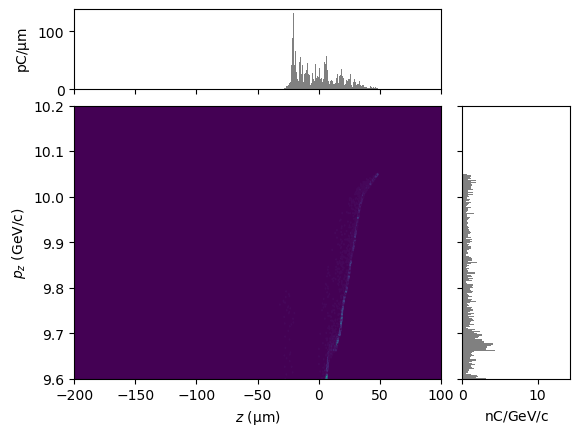

In [3]:
tao = worker({})

In [4]:
# # If needed: pip install ipywidgets matplotlib
# import ipywidgets as widgets
# import matplotlib
# from IPython.display import display
# from IPython.core.display import display, clear_output
# ts.slider()
print(tao.qpadSimPath)

/tmp/beams/qpad_sim_14794284479031833625


In [5]:
# If needed: pip install ipywidgets matplotlib
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import VBox, HBox, IntSlider, FloatText, Button, Output, Label
import matplotlib.pyplot as plt
from openpmd_viewer import OpenPMDTimeSeries
import matplotlib
from matplotlib.ticker import FuncFormatter
fold_top = tao.qpadSimPath
quant_fold = 'Species1/Charge'
fold = f'/{fold_top}/{quant_fold}/Re0/'
ts = OpenPMDTimeSeries(fold)
# print(ts.avail_fields)
# iterations = ts.iterations
# # --- widgets ---
# ndump    = IntSlider(value=3, min=0,
#                     max=len(iterations)-1, step=1, description="ndumps", continuous_update=True)
# refresh = Button(description="Update", tooltip="Redraw plot")
# out     = Output()


# fig = plt.figure(ndump.value, figsize=(6,5))

# # --- update routine ---
# def update(*_):

                        
#     # Ez, info = ts.get_field( iteration=iterations[ndump.value],  field = ts.avail_fields[0],vmin = -2, plot=True )
#     with out:
#         out.clear_output(wait=True)
#         plt.close('all')
#         print(ndump.value)
#         plt.figure(ndump.value, figsize=(6,5))
#         ax = plt.subplot(111)
#         # ax = fig.ax 
            
#         F, info = ts.get_field( iteration=iterations[ndump.value],  field = ts.avail_fields[0], plot=False )

#         plot_data = F
#         title = 'charge'
#         plt.imshow(plot_data, extent=info.imshow_extent, origin='lower',
#                    interpolation='bilinear', aspect='auto', vmin = -2)
#         plt.colorbar()
#         tick_formatter = FuncFormatter(lambda val, pos: f'{val*1e6:.f}')
#         # ax = plt.gca()
#         ax.get_xaxis().set_major_formatter( tick_formatter )
#         ax.get_yaxis().set_major_formatter( tick_formatter )
#         # plt.show()
        
#         print('plotted')
#         # fig = ts.plot_field( iteration=iterations[ndump.value],  field = ts.avail_fields[0],vmin = -2 )
#         # print(info)
#         # print(vars(info)) 
#         # F, info = ts.get_field(field="E", coord="z", iteration=it)  # F shape ≈ (nx, ny)
#         # print(Ez.shape)
#         # print(vars(info))
#         # plt.imshow(Ez.T, extent=info.imshow_extent, origin="lower", aspect="auto")
#         # plt.xlabel(info["axis_labels"][0]); plt.ylabel(info["axis_labels"][1])
#         # plt.colorbar()
        
#         # Ez, info_Ex = ts.get_field( iterations[ndump.value],  field='E', coord='z', plot=True )

# # Hook up events:
# refresh.on_click(update)
# # Auto-update when sliders/fields change (set continuous_update=False above to avoid chattiness)
# ndump.observe(update, names="value")
# # plt.close('all')
# # UI layout
# ui = VBox([
#     HBox([ndump, refresh]),
#     out
# ])

# display(ui)
# update()  # initial draw

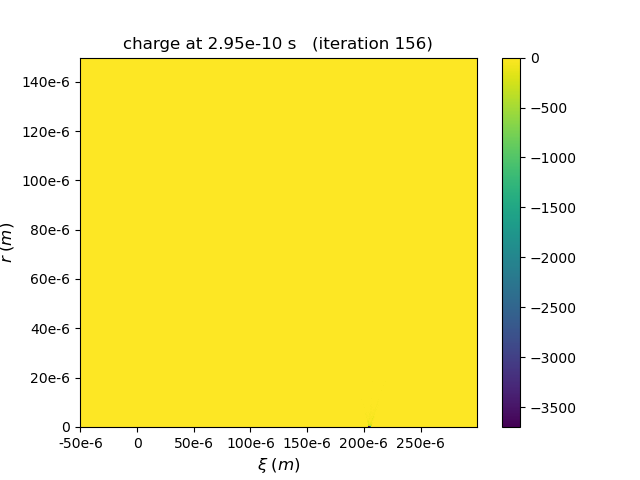

In [10]:
%matplotlib widget
# kw = {'vmin' : -2}
ts.slider(vmin = -2)

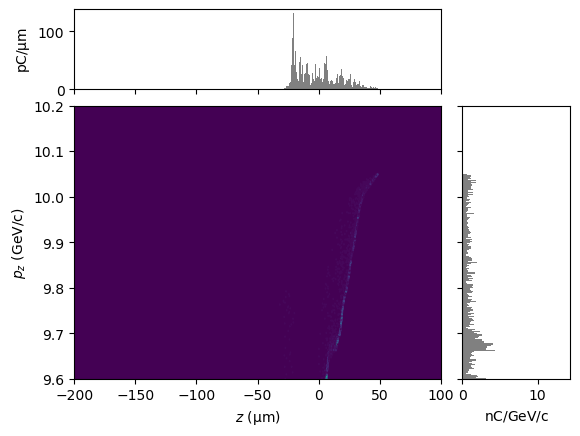

In [27]:
fold_top = tao.qpadSimPath
quant_fold = 'Beam1/Raw/'
fold =  f'/{fold_top}/{quant_fold}'
files = sorted(os.listdir(fold))

from ipywidgets import interact


def plot(niter = 0):
    P = ParticleGroup(fold+ files[4])
# P.plot('delta_t', 'pz')
P.z = -P['delta_t'] * 3e8
    plotMod(P, 'z', 'pz', bins=300, xlim = (-200e-6, 100e-6), ylim = (9.6e9, 10.2e9))

interact(plot, niters=(0,len(files)-1,1))



In [8]:
# %matplotlib widget
# Ez, info = ts.get_field( iteration=iterations[0],  field = ts.avail_fields[0],vmin = -2, plot=True )
# # plt.show()